In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/qudits_on_qubits").is_dir())
for path in (ROOT, ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
from scripts.iqm_bell_short import build_catalog, select_layout, make_plan, execute, read_samples, analyze, write_json
from qudits_on_qubits.benchmarks.direct_basis.iqm_backend import load_iqm_backend

In [2]:
DEVICE = "emerald"
REPEATS = 16
SHOTS = 256
SEED = 20260910
RUN_HARDWARE = False
CAMPAIGN = ROOT / "artifacts/iqm_bell_short/emerald_20260910"

(CVXPY) Sep 11 10:20:26 AM: Encountered unexpected exception importing solver MPAX:
ImportError('DLL load failed while importing _jax: Procedura inicjowania biblioteki dołączanej dynamicznie (DLL) nie powiodła się.')


,setting,CZ,r,depth
0,A0 / B0,6,14,12
1,A0 / B1,9,22,12
2,A0 / B2,9,22,12
3,A1 / B0,6,14,12
4,A1 / B1,9,22,12
5,A1 / B2,9,22,12
6,A2 / B0,6,14,12
7,A2 / B1,9,22,12
8,A2 / B2,9,22,12


Bell ideal: 6.000000000000005
Shots per setting and scale: 4096
Total shots: 258048


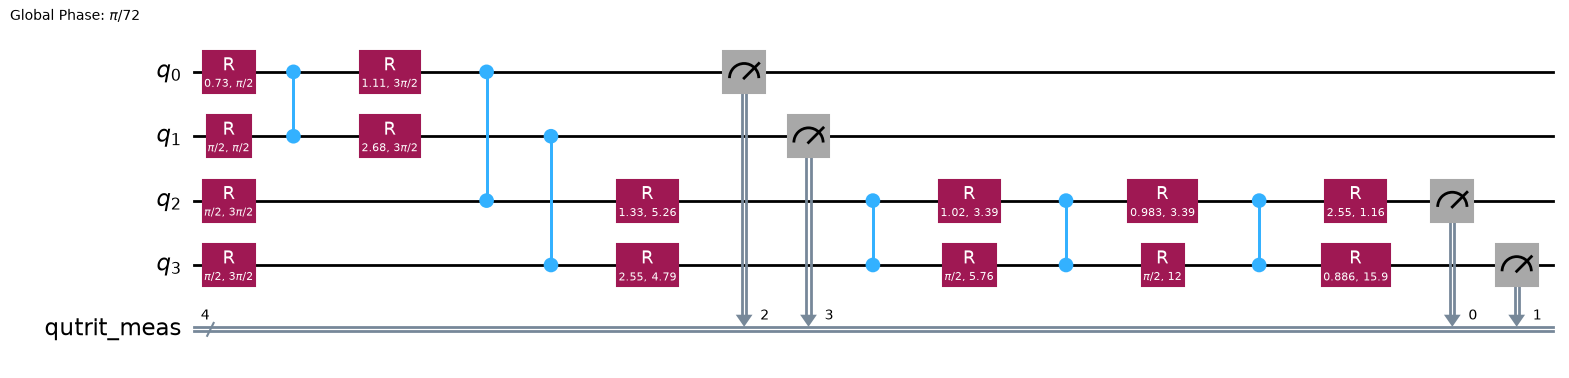

In [3]:
circuits, weights, evidence = build_catalog(ROOT)
display(pd.DataFrame([dict(setting=" / ".join(s), CZ=c.count_ops()["cz"], r=c.count_ops()["r"], depth=c.depth()) for s, c in zip(evidence["settings"], circuits)]))
print("Bell ideal:", evidence["ideal_bell"])
print("Shots per setting and scale:", REPEATS * SHOTS)
print("Total shots:", 7 * 9 * REPEATS * SHOTS)
circuits[0].draw("mpl", fold=100)

In [4]:
if RUN_HARDWARE:
    backend = load_iqm_backend(DEVICE, use_metrics=True)
    physical_circuits, selection = select_layout(circuits, backend)
    display(pd.DataFrame(selection["metrics"]))
    print("Layout:", selection["layout"], "Candidates:", selection["candidates"])
    print("Calibration:", selection["calibration_set_id"])
    plan = make_plan(physical_circuits, repeats=REPEATS, shots=SHOTS, seed=SEED)
    display(pd.DataFrame([dict(arm=j["arm"], circuits=len(j["circuits"]), shots=j["shots"], DD=j["dd"]) for j in plan]))

In [5]:
if RUN_HARDWARE:
    RUN_HARDWARE = False
    samples = execute(CAMPAIGN, plan, backend, selection, allow_hardware=True)
    write_json(CAMPAIGN / "circuit_evidence.json", evidence)
    np.save(CAMPAIGN / "bell_weights.npy", weights, allow_pickle=False)

,variant,bell,standard_error,ci95_low,ci95_high,leakage,shots
0,RAW,5.372258,0.035788,5.287633,5.456883,0.031847,36864
1,DD,5.434792,0.041927,5.335652,5.533933,0.032145,36864
2,TWIRLING,5.348621,0.061518,5.203155,5.494088,0.031657,36864
3,DD + ZNE,5.689542,0.054628,5.560369,5.818716,NaN,110592
4,TWIRLING + ZNE,5.649005,0.111325,5.385764,5.912247,NaN,110592


,scales,values,curvature,curvature_standard_error,linear_model_warning
DD,"[1, 2, 3]","[5.43479210611449, 5.126207218410283, 4.898374...",0.080752,0.103158,False
TWIRLING,"[1, 2, 3]","[5.348621332466462, 5.06853217049645, 4.758000...",-0.030442,0.145121,False


95% Student-t intervals across interleaved blocks of 2 repeats with a shot-noise floor; excludes ZNE model bias and arbitrary drift


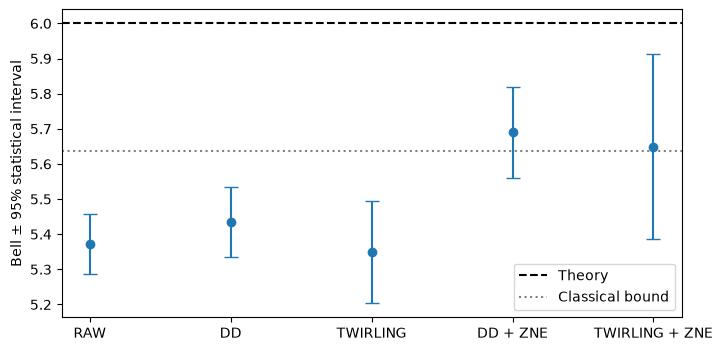

In [6]:
if (CAMPAIGN / "manifest.json").exists():
    samples = read_samples(CAMPAIGN)
    result = analyze(samples, weights)
    write_json(CAMPAIGN / "analysis.json", result)
    table = pd.DataFrame(result["rows"])
    display(table)
    display(pd.DataFrame(result["fits"]).T)
    print(result["uncertainty"])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(table["variant"], table["bell"], yerr=[table["bell"]-table["ci95_low"], table["ci95_high"]-table["bell"]], fmt="o", capsize=5)
    ax.axhline(evidence["ideal_bell"], color="black", linestyle="--", label="Theory")
    ax.axhline(evidence["classical_bound"], color="grey", linestyle=":", label="Classical bound")
    ax.set_ylabel("Bell ± 95% statistical interval")
    ax.legend()
    plt.show()

,arm,model,bell_zero,ci95_low,ci95_high,residual_dof,failed_draws,status,decaying_to_finite_offset
0,DD,linear,5.689542,5.538473,5.833741,1,0,ok,None
1,DD,quadratic,5.824129,5.317224,6.254884,0,0,interpolating,None
2,DD,exponential,5.714817,5.553467,5.870979,1,0,ok,None
3,DD,exponential_offset,5.852750,NaN,NaN,0,6,unstable,True
4,TWIRLING,linear,5.649005,5.376365,5.880754,1,0,ok,None
5,TWIRLING,quadratic,5.598268,4.991937,6.181175,0,0,interpolating,None
6,TWIRLING,exponential,5.677773,5.385356,5.929114,1,0,ok,None
7,TWIRLING,exponential_offset,5.601253,NaN,NaN,0,28,unstable,False


linear: a + b*s; quadratic: a + b*s + c*s**2; exponential: A*exp(-k*s); exponential_offset: c + A*exp(-k*s)
Ordinary least squares on Bell values; approximate 95% intervals from joint multivariate Student-t propagation across interleaved repeat blocks, with a covariance floor from shot noise. Intervals exclude model bias. No interval is reported when any uncertainty draw cannot be fitted.
A model with as many parameters as scales interpolates and cannot be validated by its residuals.
An exponential with a free offset may have no finite large-scale asymptote.
Offset exponential fits with more than three points search rates with abs(k) * (max_scale - min_scale) <= 20 and reject singular or boundary solutions.
Intermediate scales average partial folds; nonlinear noise scaling is a model assumption.
With 3 scales, polynomials of degree >= 3 are not uniquely determined; adding a * product(x - scale) leaves measured points unchanged.


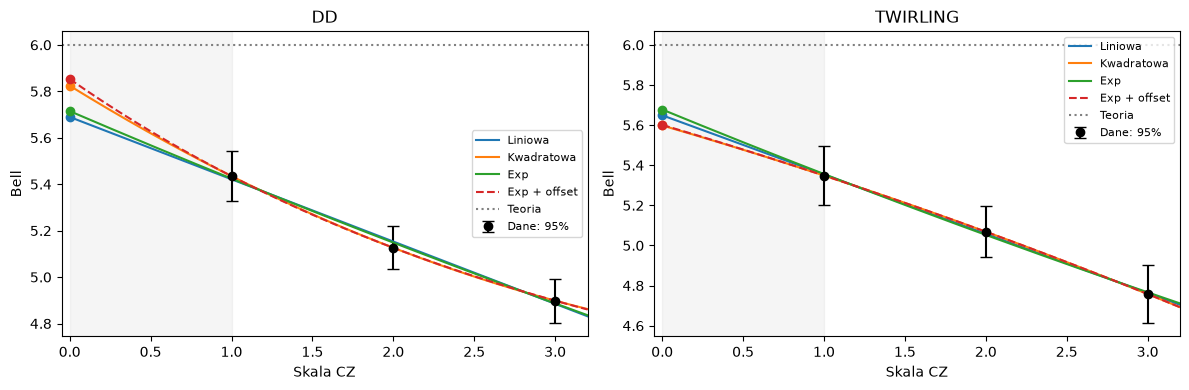

In [7]:
from scripts.iqm_bell_zne_models import compare_models, plot_comparison
if (CAMPAIGN / "bell_weights.npy").exists():
    model_comparison = compare_models(read_samples(CAMPAIGN), np.load(CAMPAIGN / "bell_weights.npy", allow_pickle=False), seed=SEED)
    write_json(CAMPAIGN / "model_comparison.json", model_comparison)
    display(pd.DataFrame(model_comparison["rows"])[["arm", "model", "bell_zero", "ci95_low", "ci95_high", "residual_dof", "failed_draws", "status", "decaying_to_finite_offset"]])
    print("linear: a + b*s; quadratic: a + b*s + c*s**2; exponential: A*exp(-k*s); exponential_offset: c + A*exp(-k*s)")
    print(model_comparison["method"])
    for warning in model_comparison["warnings"]:
        print(warning)
    print(model_comparison["unidentified_polynomials"]["reason"])
    fig = plot_comparison(model_comparison)
    fig.savefig(CAMPAIGN / "zne_model_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()
